In [1]:
# Run this cell only if you haven't installed the required packages
# NOTE: run in a notebook cell (prefix ! runs shell commands)
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm imbalanced-learn joblib openpyxl --quiet
print("Packages installed / already present.")


Packages installed / already present.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (9,6)
RANDOM_STATE = 42


In [3]:
# Update these filenames if needed
excel_file = 'oral_cancer_project_data.xlsx'
df = pd.read_excel(excel_file)
print(f"Loaded {excel_file}")

print("Shape:", df.shape)
display(df.head())

Loaded oral_cancer_project_data.xlsx
Shape: (300, 18)


,Age,Gender,Smoke_Cigarettes,Smokeless_Tobacco,Consume_Alcohol,Brush_Teeth,Fluoride_Toothpaste,Non_Healing_Ulcer,White_Red_Patches,Oral_Bleeding,Burning_Pain,Hypertension,Diabetes,Anemia,Frequent_Infections,Industrial_Exposure,Direct_Sunlight,Family_Cancer_History
0,20,1,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0
1,23,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0
2,21,0,0,0,0,1,1,1,1,1,0,0,0,1,0,0,0,0
3,20,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0
4,23,0,0,0,0,1,1,0,0,0,1,1,1,1,0,0,0,0


In [4]:
# Normalize column names (lowercase + underscores)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]  # Using single underscore
print("Columns:", df.columns.tolist())  # Correct method is tolist() (all lowercase)

# Inspect unique values for object-type columns
for c in df.columns:
    if df[c].dtype == 'object':
        print(f"\n--- Unique values in '{c}' (sample up to 10) ---")  # Proper f-string syntax
        print(df[c].dropna().unique()[:10])  # Correct slicing syntax

Columns: ['age', 'gender', 'smoke_cigarettes', 'smokeless_tobacco', 'consume_alcohol', 'brush_teeth', 'fluoride_toothpaste', 'non_healing_ulcer', 'white_red_patches', 'oral_bleeding', 'burning_pain', 'hypertension', 'diabetes', 'anemia', 'frequent_infections', 'industrial_exposure', 'direct_sunlight', 'family_cancer_history']


In [5]:
expected_cols = [
    'age','gender','smoke_cigarettes','smokeless_tobacco','consume_alcohol',
    'brush_teeth','fluoride_toothpaste','non_healing_ulcer','white_red_patches',
    'oral_bleeding','burning_pain','hypertension','diabetes','anemia',
    'frequent_infections','industrial_exposure','direct_sunlight','family_cancer_history'
]

present = [c for c in expected_cols if c in df.columns]
missing = [c for c in expected_cols if c not in df.columns]
print("Expected columns present:", present)
if missing:
    print("Expected columns missing (if these are named differently in your file, note their actual names):", missing)

# Try to auto-detect target column
potential_targets = ['oral_cancer','cancer','label','target','diagnosis','outcome']
target_col = None
for t in potential_targets:
    if t in df.columns:
        target_col = t
        break

if target_col:
    print(f"Detected target column: '{target_col}' (values:) \n{df[target_col].value_counts(dropna=False)}")
else:
    print("No target column auto-detected. If you have a target column, set `target_col` variable to its name.")
    print("Columns available:", df.columns.tolist())


Expected columns present: ['age', 'gender', 'smoke_cigarettes', 'smokeless_tobacco', 'consume_alcohol', 'brush_teeth', 'fluoride_toothpaste', 'non_healing_ulcer', 'white_red_patches', 'oral_bleeding', 'burning_pain', 'hypertension', 'diabetes', 'anemia', 'frequent_infections', 'industrial_exposure', 'direct_sunlight', 'family_cancer_history']
No target column auto-detected. If you have a target column, set `target_col` variable to its name.
Columns available: ['age', 'gender', 'smoke_cigarettes', 'smokeless_tobacco', 'consume_alcohol', 'brush_teeth', 'fluoride_toothpaste', 'non_healing_ulcer', 'white_red_patches', 'oral_bleeding', 'burning_pain', 'hypertension', 'diabetes', 'anemia', 'frequent_infections', 'industrial_exposure', 'direct_sunlight', 'family_cancer_history']


In [6]:
# --- Gender ---
if 'gender' in df.columns:
    # Convert many variants to 0/1: female=0, male=1
    df['gender'] = df['gender'].astype(str).str.strip().str.lower().map({
        'm':1,'male':1,'man':1,'1':1,'male ':1,'male.':1,
        'f':0,'female':0,'woman':0,'0':0,'female ':0
    })
    # If mapping returns NaN (e.g., empty), leave as NaN for now

# --- Age to numeric ---
if 'age' in df.columns:
    df['age'] = pd.to_numeric(df['age'], errors='coerce')

# --- Binary columns mapping ---
# We'll treat any column other than age/gender/target as binary features (attempt mapping)
binary_candidates = [c for c in df.columns if c not in (['age','gender', target_col] if target_col else ['age','gender'])]
print("Binary candidates (will try to coerce to 0/1):", binary_candidates)

for col in binary_candidates:
    # Map common text variants to 0/1
    df[col] = df[col].replace({
        True:1, False:0,
        'yes':1, 'no':0, 'y':1, 'n':0,
        'Yes':1, 'No':0, 'YES':1, 'NO':0,
        'true':1, 'false':0, 'True':1, 'False':0,
        '1':1, '0':0
    })
    # If still object (free text), try converting to numeric (coerce)
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Report missing before fill ---
print("\nMissing values before fill:")
print(df.isna().sum())

# --- Fill missing values ---
# Age -> median; Gender -> fill with mode; binary -> mode
if 'age' in df.columns:
    df['age'] = df['age'].fillna(int(df['age'].median()))  # integer age
if 'gender' in df.columns:
    if df['gender'].isna().any():
        df['gender'] = df['gender'].fillna(int(df['gender'].mode()[0]))

for col in binary_candidates:
    if df[col].isna().any():
        df[col] = df[col].fillna(int(df[col].mode()[0]))

print("\nMissing values after fill:")
print(df.isna().sum())


Binary candidates (will try to coerce to 0/1): ['smoke_cigarettes', 'smokeless_tobacco', 'consume_alcohol', 'brush_teeth', 'fluoride_toothpaste', 'non_healing_ulcer', 'white_red_patches', 'oral_bleeding', 'burning_pain', 'hypertension', 'diabetes', 'anemia', 'frequent_infections', 'industrial_exposure', 'direct_sunlight', 'family_cancer_history']

Missing values before fill:
age                      0
gender                   0
smoke_cigarettes         0
smokeless_tobacco        0
consume_alcohol          0
brush_teeth              0
fluoride_toothpaste      0
non_healing_ulcer        0
white_red_patches        0
oral_bleeding            0
burning_pain             0
hypertension             0
diabetes                 0
anemia                   0
frequent_infections      0
industrial_exposure      0
direct_sunlight          0
family_cancer_history    0
dtype: int64

Missing values after fill:
age                      0
gender                   0
smoke_cigarettes         0
smokeless_toba

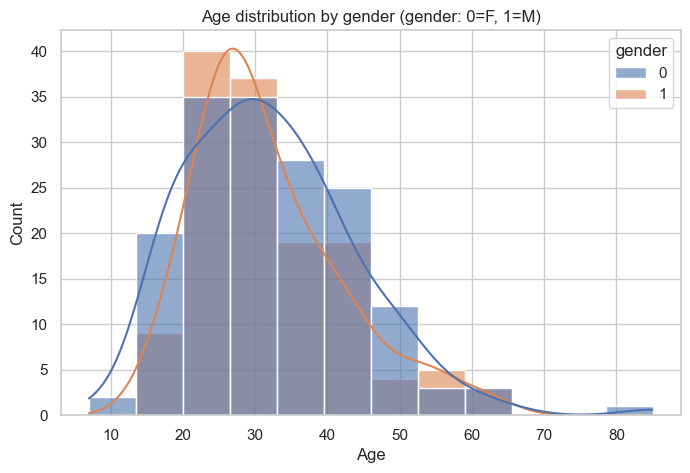

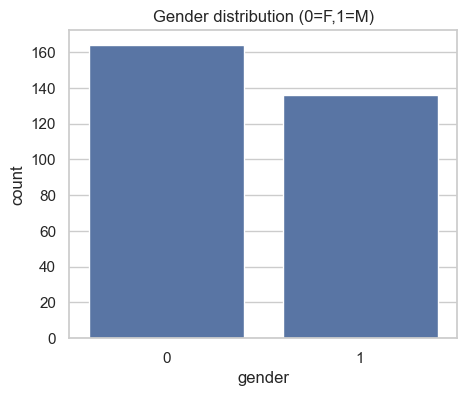

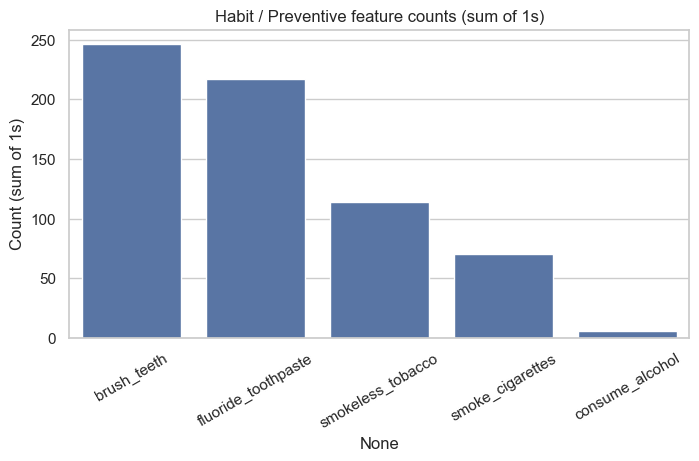

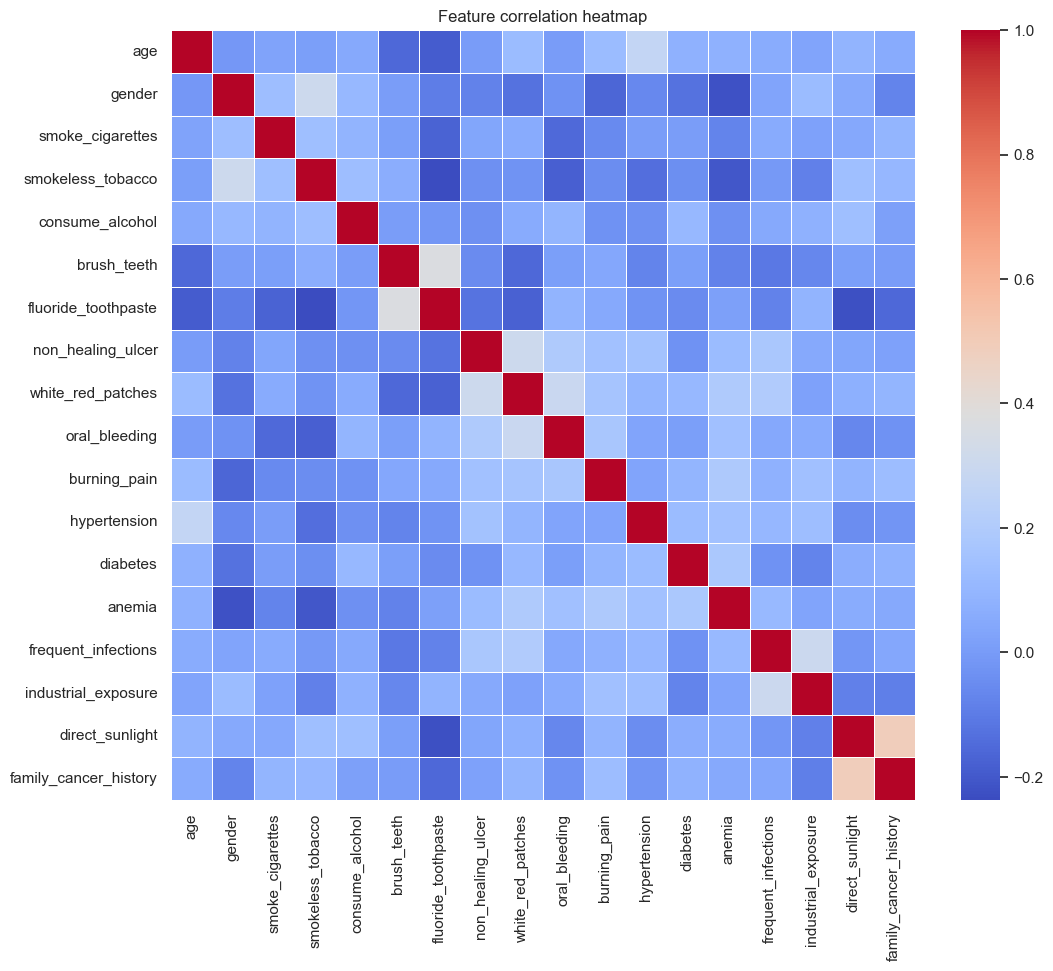

In [7]:
# Age distribution by gender
if 'age' in df.columns and 'gender' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(data=df, x='age', hue='gender', bins=12, kde=True, alpha=0.6)
    plt.title("Age distribution by gender (gender: 0=F, 1=M)")
    plt.xlabel("Age")
    plt.show()

# Gender count
if 'gender' in df.columns:
    plt.figure(figsize=(5,4))
    sns.countplot(x='gender', data=df)
    plt.title("Gender distribution (0=F,1=M)")
    plt.show()

# Habit prevalence: pick some common habit columns if present
habit_cols = [c for c in ['smoke_cigarettes','smokeless_tobacco','consume_alcohol','brush_teeth','fluoride_toothpaste'] if c in df.columns]
if habit_cols:
    habit_counts = df[habit_cols].sum().sort_values(ascending=False)
    plt.figure(figsize=(8,4))
    sns.barplot(x=habit_counts.index, y=habit_counts.values)
    plt.title("Habit / Preventive feature counts (sum of 1s)")
    plt.ylabel("Count (sum of 1s)")
    plt.xticks(rotation=30)
    plt.show()

# Full features correlation heatmap (numeric only)
plt.figure(figsize=(12,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', linewidths=0.4)
plt.title("Feature correlation heatmap")
plt.show()


In [8]:
# 1. Define your target column (replace with a valid column from df.columns)
target_col = 'non_healing_ulcer'  # Example: Choose a valid target from the list

# 2. Verify the column exists in the DataFrame
if target_col not in df.columns:
    raise ValueError(f"Column '{target_col}' not found. Available columns: {list(df.columns)}")

# Define feature columns: drop id-like and target
id_like = [c for c in ['id', 'patient_id', 'case_id'] if c in df.columns]
feature_cols = [c for c in df.columns if c not in (id_like + [target_col])]

print("Using features:", feature_cols)
print("Target:", target_col, ", distribution: \n", df[target_col].value_counts())

# Prepare features (X) and target (y)
X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()  # Ensure target is numeric (e.g., 0/1)

# Train-test split (stratify if target present)
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Using features: ['age', 'gender', 'smoke_cigarettes', 'smokeless_tobacco', 'consume_alcohol', 'brush_teeth', 'fluoride_toothpaste', 'white_red_patches', 'oral_bleeding', 'burning_pain', 'hypertension', 'diabetes', 'anemia', 'frequent_infections', 'industrial_exposure', 'direct_sunlight', 'family_cancer_history']
Target: non_healing_ulcer , distribution: 
 non_healing_ulcer
0    215
1     85
Name: count, dtype: int64
Train shape: (240, 17) Test shape: (60, 17)


In [9]:
# --- 1. Feature Scaling ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
if 'age' in X_train.columns:
    X_train['age_scaled'] = scaler.fit_transform(X_train[['age']])
    X_test['age_scaled'] = scaler.transform(X_test[['age']])

# --- 2. Advanced CPU Handling ---
import os
import warnings

# Comprehensive CPU configuration
try:
    os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 4)
    os.environ["JOBLIB_MULTIPROCESSING"] = "1"
    
    # Additional Windows-specific fix
    if os.name == 'nt':
        os.environ["NUMBA_DISABLE_PERFORMANCE_WARNINGS"] = "1"
        os.environ["OMP_NUM_THREADS"] = "1"
        
except Exception as e:
    print(f"CPU configuration warning: {str(e)}")
    os.environ["LOKY_MAX_CPU_COUNT"] = "4"  # Fallback value

# Suppress all loky/joblib warnings
warnings.filterwarnings("ignore", category=UserWarning, module="loky")
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")

# --- 3. Class Imbalance Handling ---
from imblearn.over_sampling import SMOTE
import numpy as np

apply_smote = True
if apply_smote:
    sm = SMOTE(random_state=RANDOM_STATE)
    X_res, y_res = sm.fit_resample(X_train.fillna(0), y_train)
    print("After SMOTE, label counts:", np.bincount(y_res))
else:
    X_res, y_res = X_train.fillna(0), y_train

# --- 4. Model Training ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Initialize models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
}

# Train models
trained = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_res, y_res)
    trained[name] = model
    print(f"{name} done.\n")

print("All models trained successfully!")

After SMOTE, label counts: [172 172]
Training LogisticRegression...
LogisticRegression done.

Training RandomForest...
RandomForest done.

Training XGBoost...
XGBoost done.

All models trained successfully!


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)  # Removed `use_label_encoder`
}

trained = {}
for name, model in models.items():
    print(f"Training {name}...")  # Fixed f-string (no parentheses)
    model.fit(X_res, y_res)      # Ensure `X_res` is correct (not `x_res`)
    trained[name] = model
    print(f"{name} done.\n")     # Fixed f-string and newline


Training LogisticRegression...
LogisticRegression done.

Training RandomForest...
RandomForest done.

Training XGBoost...
XGBoost done.



=== LogisticRegression ===
Accuracy: 0.4833
Classification report:
               precision    recall  f1-score   support

           0       0.68      0.53      0.60        43
           1       0.23      0.35      0.28        17

    accuracy                           0.48        60
   macro avg       0.45      0.44      0.44        60
weighted avg       0.55      0.48      0.51        60

Confusion matrix:
 [[23 20]
 [11  6]]
ROC AUC: 0.4747
----------------------------------------
=== RandomForest ===
Accuracy: 0.6833
Classification report:
               precision    recall  f1-score   support

           0       0.77      0.79      0.78        43
           1       0.44      0.41      0.42        17

    accuracy                           0.68        60
   macro avg       0.61      0.60      0.60        60
weighted avg       0.68      0.68      0.68        60

Confusion matrix:
 [[34  9]
 [10  7]]
ROC AUC: 0.5698
----------------------------------------
=== XGBoost ===
Accuracy: 

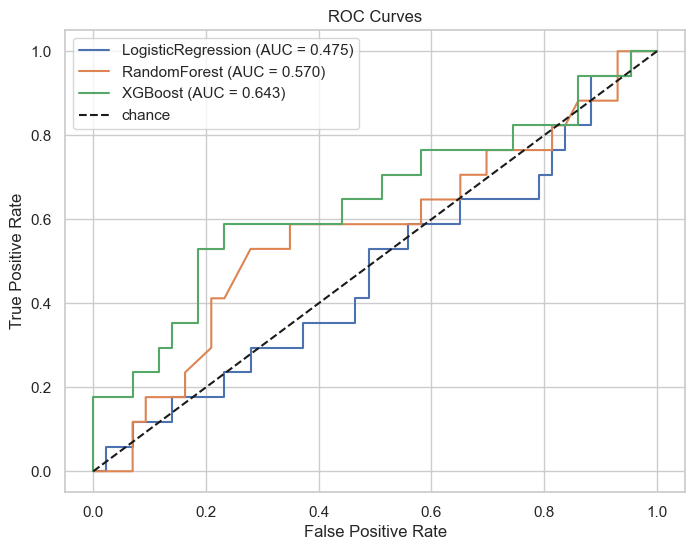

In [11]:
plt.figure(figsize=(8,6))
for name, model in trained.items():
    # Prepare test data (ensure same columns)
    X_test_prep = X_test.fillna(0)
    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:,1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    print(f"=== {name} ===")
    print("Accuracy:", round(acc,4))
    print("Classification report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion matrix:\n", cm)

    if y_proba is not None:
        roc = roc_auc_score(y_test, y_proba)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc:.3f})")
        print("ROC AUC:", round(roc,4))
    print("-"*40)

# Plot ROC curves (if available)
plt.plot([0,1],[0,1],'k--',label='chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


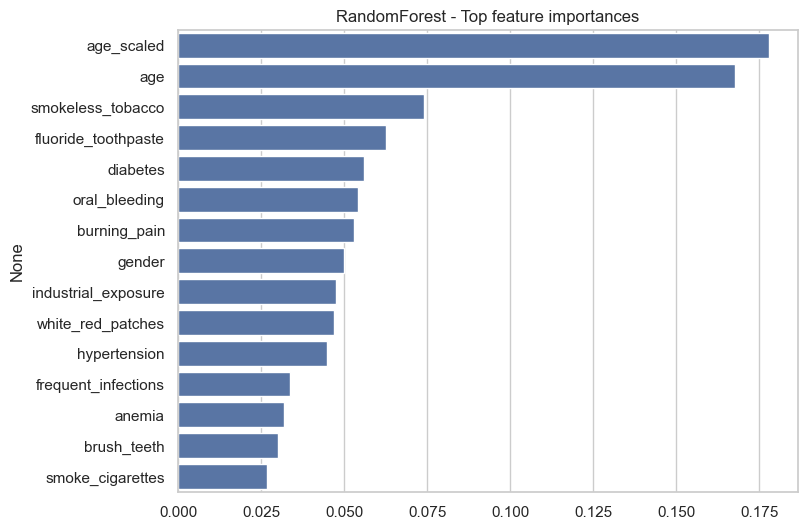

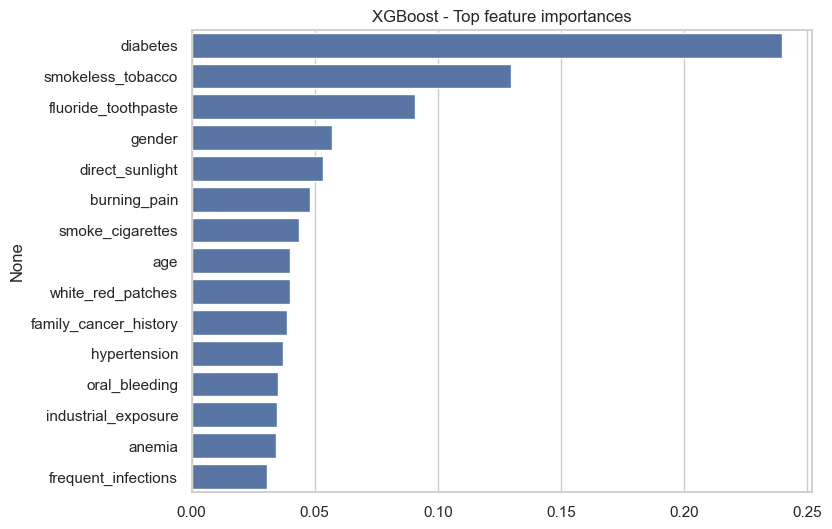

In [12]:
# Feature importance for RandomForest
if 'RandomForest' in trained:
    rf = trained['RandomForest']
    importances = rf.feature_importances_
    feat_imp = pd.Series(importances, index=X_res.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,6))
    sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15])
    plt.title("RandomForest - Top feature importances")
    plt.show()

# For XGBoost
if 'XGBoost' in trained:
    xgb = trained['XGBoost']
    try:
        importances = xgb.feature_importances_
        feat_imp = pd.Series(importances, index=X_res.columns).sort_values(ascending=False)
        plt.figure(figsize=(8,6))
        sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15])
        plt.title("XGBoost - Top feature importances")
        plt.show()
    except Exception as e:
        print("Could not get XGBoost importances:", e)


In [13]:
# Choose a model to save. Here we pick the model with highest test ROC AUC (if available).
best_name = None
best_auc = -1
X_test_prep = X_test.fillna(0)

for name, model in trained.items():
    if hasattr(model, "predict_proba"):
        auc_score = roc_auc_score(y_test, model.predict_proba(X_test_prep)[:,1])
        print(f"{name} AUC = {auc_score:.4f}")
        if auc_score > best_auc:
            best_auc = auc_score
            best_name = name

if best_name is None:
    # fallback to accuracy selection
    best_acc = 0
    for name, model in trained.items():
        acc = accuracy_score(y_test, model.predict(X_test_prep))
        if acc > best_acc:
            best_acc = acc
            best_name = name

print(f"Best model chosen: {best_name}")
joblib.dump(trained[best_name], f"oral_cancer_model_{best_name}.joblib")
print(f"Saved model to oral_cancer_model_{best_name}.joblib")


LogisticRegression AUC = 0.4747
RandomForest AUC = 0.5698
XGBoost AUC = 0.6430
Best model chosen: XGBoost
Saved model to oral_cancer_model_XGBoost.joblib


In [14]:
# Tips:
# 1) If dataset is small, prefer cross-validation and simpler models (LogReg, RF).
# 2) Tune hyperparameters with GridSearchCV or RandomizedSearchCV.
# 3) Use SHAP or LIME for model explainability (especially for medical work).
# 4) If you want, set apply_smote=False and compare results (SMOTE can help if imbalance is strong).
# 5) Keep a clear train/test split and/or use k-fold CV to avoid overfitting.

print("Notebook run completed. Review charts and metrics and tune as needed.")


Notebook run completed. Review charts and metrics and tune as needed.
